In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import matplotlib.colors as colors
from mpl_toolkits import mplot3d
from math import sqrt
import warnings
import time

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.model_selection import train_test_split,KFold,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder, MinMaxScaler


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,ExtraTreesRegressor,BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.models import load_model

import pickle
import os
import random

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams["savefig.format"] = 'tiff'
warnings.filterwarnings("ignore")

In [2]:
seed = 76
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.7)


In [4]:
# Learning Rate Scheduler
def scheduler(epoch, lr):
  if epoch < 160:
    return lr
  else:
    return lr * np.exp(-0.1)

callback = keras.callbacks.LearningRateScheduler(scheduler)



# Neural Network
def Neural_network():
    init = keras.initializers.random_normal()
    model=Sequential()
    model.add(layers.Dense(64,activation='relu',kernel_initializer=init, input_dim=scaled_DF.shape[1]))
    model.add(layers.Dropout(0.1))


    model.add(layers.Dense(64,activation='relu',kernel_initializer=init))
    model.add(layers.Dropout(0.1))

    model.add(layers.Dense(1,kernel_initializer=init,activation = 'linear'))


    optimize=tf.keras.optimizers.Adam()

    model.compile(optimizer=optimize,
                    loss='mse',
                    )
    return model



In [5]:
# Funtion to train the model
def training_model(X_train,Y_train,model):
    history=model.fit(X_train,Y_train,epochs=200,batch_size=32,verbose=0,callbacks=[callback])
    return history

In [6]:
# To print losses
def plots():
    f, ax = plt.subplots(1,1)
    actual_test=np.array(scaler.inverse_transform(testY).reshape(-1,1))
    predicted_test=np.array(scaler.inverse_transform(model.predict(testX).reshape(-1,1)))

    #actual=testY
    #predicted= model.predict(testX)

    actual=np.array(scaler.inverse_transform(np.array(trainY).reshape(-1,1)))
    predicted=np.array(scaler.inverse_transform(model.predict(np.array(trainX)).reshape(-1,1)))

    plt.rcParams["figure.figsize"] = (6,6)
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams["savefig.format"] = 'tiff'

    sns.set(style='whitegrid')
    sns.set_context("paper", font_scale=1.7)

    plt.scatter(actual_test,predicted_test, color='purple', label='Test', linewidths=1, edgecolors='black', s=75)
    sns.regplot(x=actual,y=predicted, color='orangered', label='Train', scatter_kws={'s':40, 'alpha':0.5, 'edgecolor':'black'})

    print("Mean absolute error (MAE) - Test:      %f" % mean_absolute_error(actual_test,predicted_test))
    print("Mean squared error (MSE) - Test:       %f" % mean_squared_error(actual_test,predicted_test))
    print("Root mean squared error (RMSE) - Test: %f" % sqrt(mean_squared_error(actual_test,predicted_test)))
    print("R square (R^2):                 %f" % r2_score(actual_test,predicted_test))


    plt.xlabel("Actual")
    plt.ylabel('Predicted')
    anchored_text = AnchoredText("R\u00b2 Score_train  "+str(round(r2_score(actual,predicted),3))+'\n'"R\u00b2 Score_test  "+str(round(r2_score(actual_test,predicted_test),3)), loc=2,prop=dict(size=10))
    ax.add_artist(anchored_text)

    plt.legend(loc = 9, prop={'size': 10})
    plt.tight_layout()
    plt.savefig(str(model)[1:6], bbox_inches='tight')

In [7]:
def defining_model(x):
    if x == 'mlr':
      model = LinearRegression()
    elif x=='adboost':
      model = AdaBoostRegressor(random_state=42)
    elif x=='xtratree':
      model = ExtraTreesRegressor(random_state=42)
    elif x=='bagging':
      model = BaggingRegressor(random_state=42)
    elif x=='pls':
      model = PLSRegression()
    elif x=='rndmfrst':
      model = RandomForestRegressor(random_state=42)
    elif x=='knn':
      model = KNeighborsRegressor()
    elif x=='svr':
      model = SVR()
    else:
      print("wrong selection")
    return model


In [8]:
df = pd.read_excel(
    'data_final.xlsx'
)

In [9]:
df.shape

(227, 174)

In [10]:
df.head(2)

,Type,ID,Name,Cation smiles,Anion smiles,ET30,ABC,nBase,SpMax_A,VR1_A,...,An_EState_VSA2,An_EState_VSA4,An_EState_VSA5,An_EState_VSA8,An_EState_VSA9,An_VSA_EState3,An_VSA_EState7,An_AMID_O,An_AMID_X,An_n6HRing
0,ammonium salts,A1,[NH4] F3CCO2,[NH4+],FC(F)(C([O-])=O)F,43.6,0.000000,1,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,9.901065,8.784722,-5.194444,0.475336,0.709501,0
1,ammonium salts,A2,[EtNH3] Cl,CC[NH3+],[Cl-],62.3,1.414214,1,1.414214,3.363586,...,12.407033,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0


In [ ]:
with open('train_ids.pkl', 'rb') as f:
    train_ids = pickle.load(f)


with open('test_ids.pkl', 'rb') as f:
    test_ids = pickle.load(f)

Train = df[df['ID'].isin(train_ids)].set_index('ID').loc[train_ids].reset_index()
Test = df[df['ID'].isin(test_ids)]

In [13]:
Train.head(3)

,ID,Type,Name,Cation smiles,Anion smiles,ET30,ABC,nBase,SpMax_A,VR1_A,...,An_EState_VSA2,An_EState_VSA4,An_EState_VSA5,An_EState_VSA8,An_EState_VSA9,An_VSA_EState3,An_VSA_EState7,An_AMID_O,An_AMID_X,An_n6HRing
0,I21,imidazolium salts,[MeO(CH₂)2mim] NTf₂,CN1C=C[N+](CCOC)=C1,FC(F)(F)S(=O)([N-]S(=O)(C(F)(F)F)=O)=O,54.1,7.180458,1,2.236324,46.151834,...,0.000000,4.127401,0.000000,0.000000,0.000000,0.000000,0.000000,0.453779,0.667042,0
1,I162,imidazolium salts,[mim] CH3CH2CO2,C[N+]1=CNC=C1,CCC([O-])=O,47.0,4.352030,1,2.114908,14.516293,...,6.420822,0.000000,6.923737,0.000000,0.000000,9.256944,0.111111,0.662611,0.000000,0
2,I43,imidazolium salts,[hmim] F3CSO₃,C[N+]1=CN(CCCCCC)C=C1,FC(F)(S(=O)([O-])=O)F,52.5,8.594671,1,2.237905,103.592000,...,0.000000,0.000000,0.000000,0.000000,12.970547,0.000000,0.000000,0.621094,0.621094,0
3,I34,imidazolium salts,[bmim] NO₃,C[N+]1=CN(CCCC)C=C1,O=[N+]([O-])[O-],51.8,7.180458,1,2.236324,46.151834,...,0.000000,0.000000,0.000000,0.000000,15.321571,14.750000,0.000000,1.216506,0.000000,0
4,I30,imidazolium salts,[HO(CH₂)2mim] N(CN)₂,C[N+]1=CN(CCO)C=C1,N#C[N-]C#N,56.1,6.473351,1,2.233210,32.456802,...,0.000000,0.000000,12.386312,5.316789,10.523783,17.437500,2.562500,0.000000,0.000000,0


In [14]:
# Combine Train and test for feature engineering
DF_raw = pd.concat([Train,Test],ignore_index=True)
DF_data = DF_raw.copy()

In [15]:
# Removing Unwanted columns
DF_data=DF_data.drop(['Type', 'ID', 'Name', 'Cation smiles', 'Anion smiles'],axis=1)
DF_data.head(3)

,ET30,ABC,nBase,SpMax_A,VR1_A,nAromAtom,nHetero,nN,nO,nS,...,An_EState_VSA2,An_EState_VSA4,An_EState_VSA5,An_EState_VSA8,An_EState_VSA9,An_VSA_EState3,An_VSA_EState7,An_AMID_O,An_AMID_X,An_n6HRing
0,54.1,7.180458,1,2.236324,46.151834,5,3,2,1,0,...,0.000000,4.127401,0.000000,0.0,0.000000,0.000000,0.000000,0.453779,0.667042,0
1,47.0,4.352030,1,2.114908,14.516293,5,2,2,0,0,...,6.420822,0.000000,6.923737,0.0,0.000000,9.256944,0.111111,0.662611,0.000000,0
2,52.5,8.594671,1,2.237905,103.592000,5,2,2,0,0,...,0.000000,0.000000,0.000000,0.0,12.970547,0.000000,0.000000,0.621094,0.621094,0


In [16]:

# Scaling the whole DataFrame

scaler = StandardScaler()
scaled_DF = pd.DataFrame(scaler.fit_transform(DF_data.iloc[:,1:]))
scaled_DF.columns = DF_data.iloc[:,1:].columns

scaled_DF['ET30'] = scaler.fit_transform(np.array(DF_data['ET30']).reshape(-1,1))


In [17]:
DF_target = scaled_DF[['ET30']]
scaled_DF.drop('ET30',axis=1,inplace=True)

display(scaled_DF)
display(DF_target)

,ABC,nBase,SpMax_A,VR1_A,nAromAtom,nHetero,nN,nO,nS,nP,...,An_EState_VSA2,An_EState_VSA4,An_EState_VSA5,An_EState_VSA8,An_EState_VSA9,An_VSA_EState3,An_VSA_EState7,An_AMID_O,An_AMID_X,An_n6HRing
0,-0.578748,-0.164771,-0.000758,-0.283371,1.160318,1.059365,0.466964,1.035027,-0.094281,-0.23625,...,-0.492714,0.713627,-0.604624,-0.520293,-0.785601,-0.719014,-0.172629,0.095291,0.475055,-0.191127
1,-1.157673,-0.164771,-0.565628,-0.315649,1.160318,-0.014188,0.466964,-0.490630,-0.094281,-0.23625,...,0.662132,-0.612659,0.649566,-0.520293,-0.785601,0.541244,-0.112588,0.631331,-0.947412,-0.191127
2,-0.289286,-0.164771,0.006596,-0.224766,1.160318,-0.014188,0.466964,-0.490630,-0.094281,-0.23625,...,-0.492714,-0.612659,-0.604624,-0.520293,1.297709,-0.719014,-0.172629,0.524764,0.377070,-0.191127
3,-0.578748,-0.164771,-0.000758,-0.283371,1.160318,-0.014188,0.466964,-0.490630,-0.094281,-0.23625,...,-0.492714,-0.612659,-0.604624,-0.520293,1.675328,1.289080,-0.172629,2.053098,-0.947412,-0.191127
4,-0.723479,-0.164771,-0.015248,-0.297344,1.160318,1.059365,0.466964,1.035027,-0.094281,-0.23625,...,-0.492714,-0.612659,1.639077,1.343299,0.904714,1.654961,1.212056,-1.069490,-0.947412,-0.191127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,-0.423880,-0.164771,0.328836,-0.260072,-0.776389,-1.087741,-0.765604,-0.490630,-0.094281,-0.23625,...,-0.492714,0.713627,-0.604624,-0.520293,-0.785601,-0.719014,-0.172629,0.095291,0.475055,-0.191127
223,0.010314,-0.164771,0.331232,-0.022210,-0.776389,-1.087741,-0.765604,-0.490630,-0.094281,-0.23625,...,-0.492714,0.713627,-0.604624,-0.520293,-0.785601,-0.719014,-0.172629,0.095291,0.475055,-0.191127
224,-0.401490,-0.164771,0.421038,-0.284094,-0.776389,1.059365,-0.765604,2.560683,-0.094281,-0.23625,...,-0.492714,0.713627,-0.604624,-0.520293,-0.785601,-0.719014,-0.172629,0.095291,0.475055,-0.191127
225,0.411979,6.069047,0.873103,0.274351,-0.776389,-0.014188,0.466964,-0.490630,-0.094281,-0.23625,...,-0.492714,-0.612659,1.639077,1.343299,0.904714,1.654961,1.212056,-1.069490,-0.947412,-0.191127


,ET30
0,0.522553
1,-0.838906
2,0.215745
3,0.081517
4,0.906063
...,...
222,-0.455397
223,1.078642
224,2.440101
225,-0.512923


In [18]:
trainX = scaled_DF[:len(Train)]
testX = scaled_DF[len(Train):]

trainY = DF_target[:len(Train)]
testY = DF_target[len(Train):]

In [19]:
trainX.shape

(177, 168)

In [20]:
testX.shape

(50, 168)

## **Model screening with 168 descriptors**




In [21]:
totalX = pd.concat([trainX, testX], axis=0)
totalY = pd.concat([trainY, testY], axis=0)

Average validation R2 score after crossvalidation :  -37713.507035859264
Average validation rmse score after crossvalidation :  637.8164915207253


Training Accuracy :  0.9369068251233257
Mean absolute error (MAE) - Test:      2.331547
Mean squared error (MSE) - Test:       11.060585
Root mean squared error (RMSE) - Test: 3.325746
R square (R^2):                 0.694261


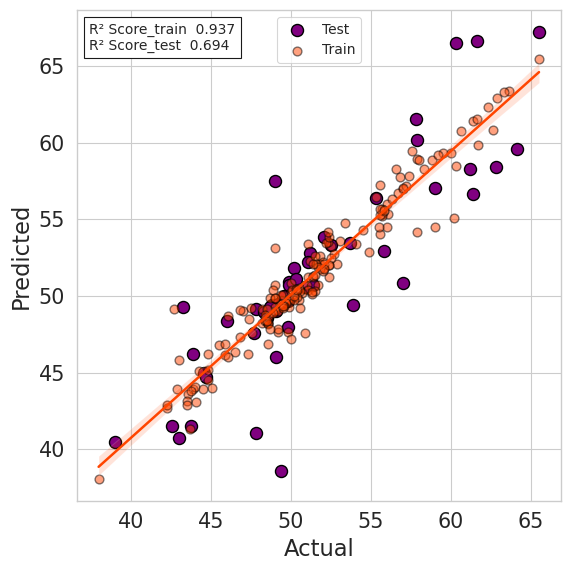

In [22]:
# Multiple Linear Regression


kfold = KFold(n_splits=5, shuffle=True, random_state=42)
model = defining_model(x = 'mlr')
scores = []
rmse = []
for train,valid in kfold.split(trainX,trainY):
  model.fit(trainX.iloc[train],trainY.iloc[train])
  scores.append(model.score(trainX.iloc[valid],trainY.iloc[valid]))
  actual = trainY.iloc[valid]
  predicted = model.predict(trainX.iloc[valid])
  rmse.append(sqrt(mean_squared_error(scaler.inverse_transform(actual),scaler.inverse_transform(predicted))))


print("Average validation R2 score after crossvalidation : ", np.mean(scores))
print("Average validation rmse score after crossvalidation : ", np.mean(rmse))

# Train model on whole train data
model = defining_model(x = 'mlr')
model.fit(trainX,trainY)
print("\n\nTraining Accuracy : ",model.score(trainX,trainY)) # Training Accuracy
plots()

Average validation R2 score after crossvalidation :  0.48827521242406646
Average validation rmse score after crossvalidation :  3.5228274884792


Training Accuracy :  0.7149091097796854
Mean absolute error (MAE) - Test:      2.306198
Mean squared error (MSE) - Test:       9.090914
Root mean squared error (RMSE) - Test: 3.015114
R square (R^2):                 0.748707


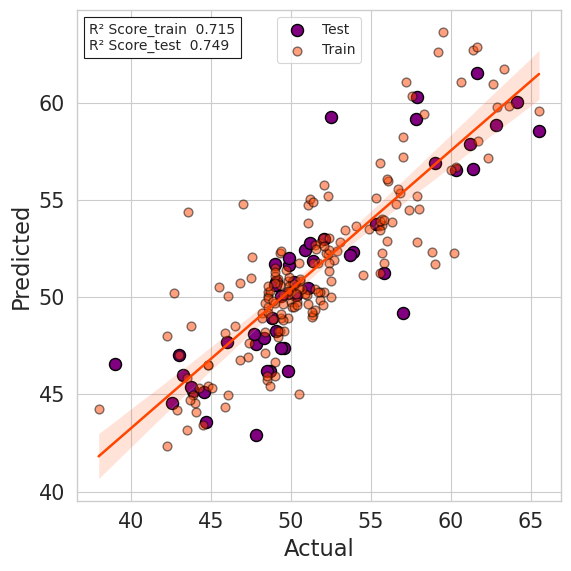

In [23]:
# Partial Least Square
model = defining_model(x = 'pls')

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []
rmse = []
for train,valid in kfold.split(trainX,trainY):
  model.fit(trainX.iloc[train],trainY.iloc[train])
  scores.append(model.score(trainX.iloc[valid],trainY.iloc[valid]))
  actual = trainY.iloc[valid]
  predicted = model.predict(trainX.iloc[valid])
  rmse.append(sqrt(mean_squared_error(scaler.inverse_transform(actual),scaler.inverse_transform(predicted))))


print("Average validation R2 score after crossvalidation : ", np.mean(scores))
print("Average validation rmse score after crossvalidation : ", np.mean(rmse))

# Train model on whole train data
model = defining_model(x = 'pls')
model.fit(trainX,trainY)
print("\n\nTraining Accuracy : ",model.score(trainX,trainY)) # Training Accuracy
plots()

Average validation R2 score after crossvalidation :  0.4890731028583257
Average validation rmse score after crossvalidation :  3.518321312307658


Training Accuracy :  0.6764241914603701
Mean absolute error (MAE) - Test:      2.175200
Mean squared error (MSE) - Test:       9.274080
Root mean squared error (RMSE) - Test: 3.045337
R square (R^2):                 0.743644


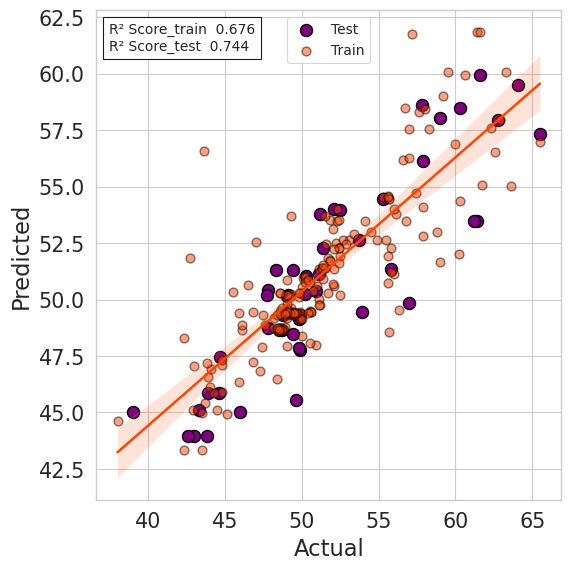

In [24]:
# KNN
model = defining_model(x = 'knn')

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []
rmse = []
for train,valid in kfold.split(trainX,trainY):
  model.fit(trainX.iloc[train],trainY.iloc[train])
  scores.append(model.score(trainX.iloc[valid],trainY.iloc[valid]))
  actual = trainY.iloc[valid]
  predicted = model.predict(trainX.iloc[valid])
  rmse.append(sqrt(mean_squared_error(scaler.inverse_transform(actual),scaler.inverse_transform(predicted))))


print("Average validation R2 score after crossvalidation : ", np.mean(scores))
print("Average validation rmse score after crossvalidation : ", np.mean(rmse))

# Train model on whole train data
model = defining_model(x = 'knn')
model.fit(trainX,trainY)
print("\n\nTraining Accuracy : ",model.score(trainX,trainY)) # Training Accuracy
plots()

Average validation R2 score after crossvalidation :  0.6085453833546248
Average validation rmse score after crossvalidation :  3.0876855095008664


Training Accuracy :  0.8751229549982871
Mean absolute error (MAE) - Test:      2.054811
Mean squared error (MSE) - Test:       8.177928
Root mean squared error (RMSE) - Test: 2.859708
R square (R^2):                 0.773944


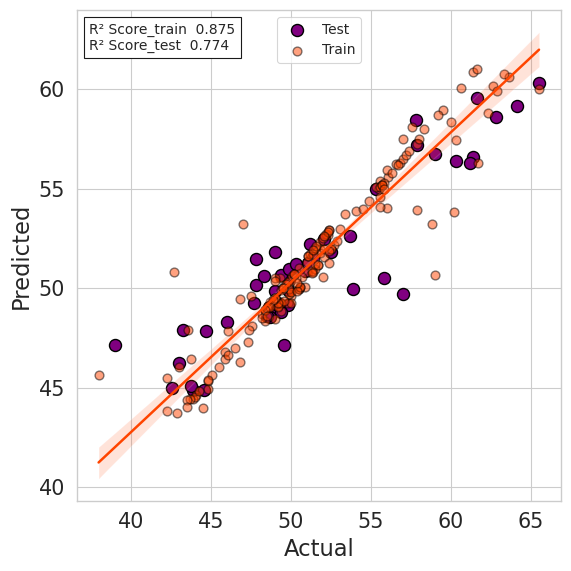

In [25]:
# Support Vector Regressor
model = defining_model(x = 'svr')

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []
rmse = []
for train,valid in kfold.split(trainX,trainY):
  model.fit(trainX.iloc[train],trainY.iloc[train])
  scores.append(model.score(trainX.iloc[valid],trainY.iloc[valid]))
  actual = trainY.iloc[valid]
  predicted = model.predict(trainX.iloc[valid])
  rmse.append(sqrt(mean_squared_error(scaler.inverse_transform(actual),scaler.inverse_transform(predicted.reshape(-1,1)))))


print("Average validation R2 score after crossvalidation : ", np.mean(scores))
print("Average validation rmse score after crossvalidation : ", np.mean(rmse))

# Train model on whole train data
model = defining_model(x = 'svr')
model.fit(trainX,trainY)
print("\n\nTraining Accuracy : ",model.score(trainX,trainY)) # Training Accuracy
plots()

Average validation R2 score after crossvalidation :  0.5253155286184834
Average validation rmse score after crossvalidation :  3.372276107025413


Training Accuracy :  0.8389961156768257
Mean absolute error (MAE) - Test:      1.944710
Mean squared error (MSE) - Test:       6.656450
Root mean squared error (RMSE) - Test: 2.580010
R square (R^2):                 0.816001


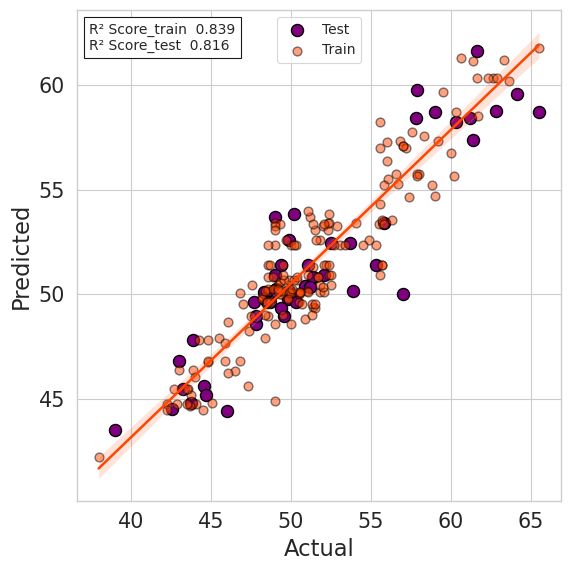

In [26]:
#Adaboost
model = defining_model(x = 'adboost')
kfold = KFold(n_splits=5, shuffle=True)

scores = []
rmse = []
for train,valid in kfold.split(trainX,trainY):
  model.fit(trainX.iloc[train],trainY.iloc[train])
  scores.append(model.score(trainX.iloc[valid],trainY.iloc[valid]))
  actual = trainY.iloc[valid]
  predicted = model.predict(trainX.iloc[valid])
  rmse.append(sqrt(mean_squared_error(scaler.inverse_transform(actual),scaler.inverse_transform(predicted.reshape(-1,1)))))

print("Average validation R2 score after crossvalidation : ", np.mean(scores))
print("Average validation rmse score after crossvalidation : ", np.mean(rmse))


# Train model on whole train data
model = defining_model(x = 'adboost')
model.fit(trainX,trainY)
print("\n\nTraining Accuracy : ",model.score(trainX,trainY)) # Training Accuracy
plots()

Average validation R2 score after crossvalidation :  0.7372914028172625
Average validation rmse score after crossvalidation :  2.624984735792549


Training Accuracy :  1.0
Mean absolute error (MAE) - Test:      1.446560
Mean squared error (MSE) - Test:       4.654119
Root mean squared error (RMSE) - Test: 2.157341
R square (R^2):                 0.871350


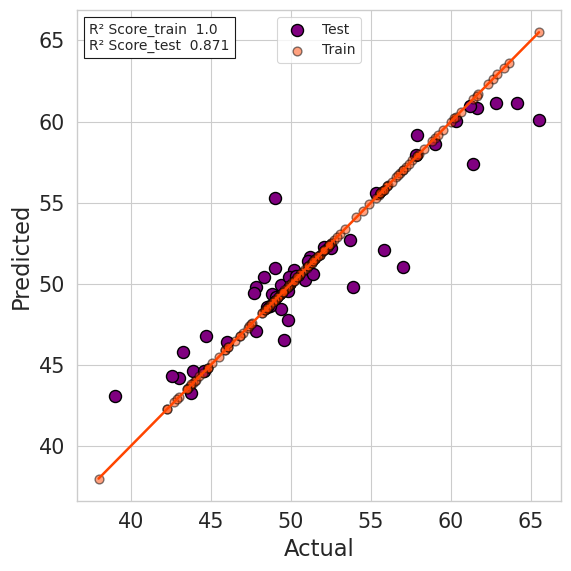

In [27]:
# Extra Tree Regressor
model = defining_model(x = 'xtratree')
kfold = KFold(n_splits=5, shuffle=True)

scores = []
rmse = []
for train,valid in kfold.split(totalX,totalY):
  model = defining_model(x = 'xtratree')
  model.fit(totalX.iloc[train],totalY.iloc[train])
  scores.append(model.score(totalX.iloc[valid],totalY.iloc[valid]))
  actual = totalY.iloc[valid]
  predicted = model.predict(totalX.iloc[valid])
  rmse.append(sqrt(mean_squared_error(scaler.inverse_transform(actual),scaler.inverse_transform(predicted.reshape(-1,1)))))

print("Average validation R2 score after crossvalidation : ", np.mean(scores))
print("Average validation rmse score after crossvalidation : ", np.mean(rmse))


# Train model on whole train data
model = defining_model(x = 'xtratree')
model.fit(trainX,trainY)
print("\n\nTraining Accuracy : ",model.score(trainX,trainY)) # Training Accuracy
plots()

In [28]:
# get importance
importance = model.feature_importances_
# summarize feature importance
dicts = {
    'Feature':[x for x in trainX.columns],
    'Importance':importance
    }
DF_imp = pd.DataFrame(dicts)
DF_imp = DF_imp.sort_values('Importance',ascending=False)
# DF_imp.to_excel('imp.xlsx', index=None)

In [29]:
imp = pd.read_excel('imp.xlsx')

In [30]:
imp['Importance'] = round(imp['Importance'],2)

Text(0, 0.5, 'Feature Importance')

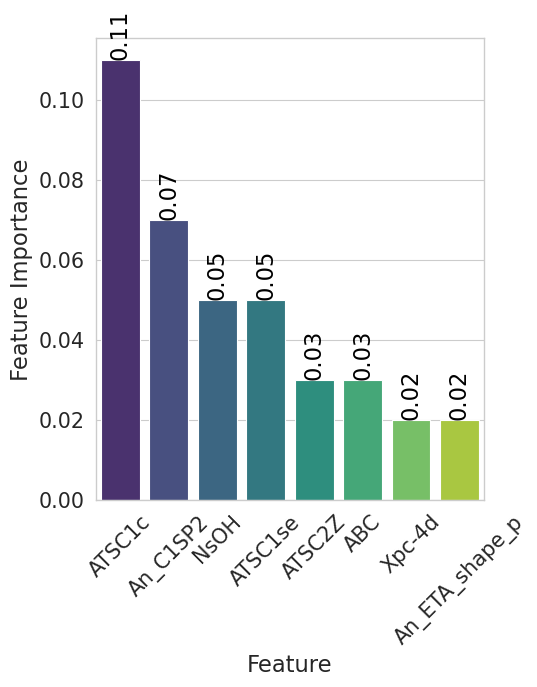

In [31]:
sns.set_context("paper", font_scale=1.7)
fig, ax = plt.subplots(figsize=(5, 6))
ba = sns.barplot(x = 'Feature', y='Importance', data=imp.iloc[:8,:], palette="viridis", )
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2., 1.00 * height,
                height,
                ha='center', va='bottom', rotation=90, color='black')
labels = imp['Feature'][:8]
autolabel(ax.patches)
ba.set_xticklabels(labels =labels, rotation=45)
plt.ylabel( 'Feature Importance')
# plt.savefig('featureimp.tiff', bbox_inches='tight')

Average validation R2 score after crossvalidation :  0.6974836331223251
Average validation rmse score after crossvalidation :  2.8402160400132677


Training Accuracy :  0.9409700584884099
Mean absolute error (MAE) - Test:      1.618780
Mean squared error (MSE) - Test:       5.371652
Root mean squared error (RMSE) - Test: 2.317682
R square (R^2):                 0.851515


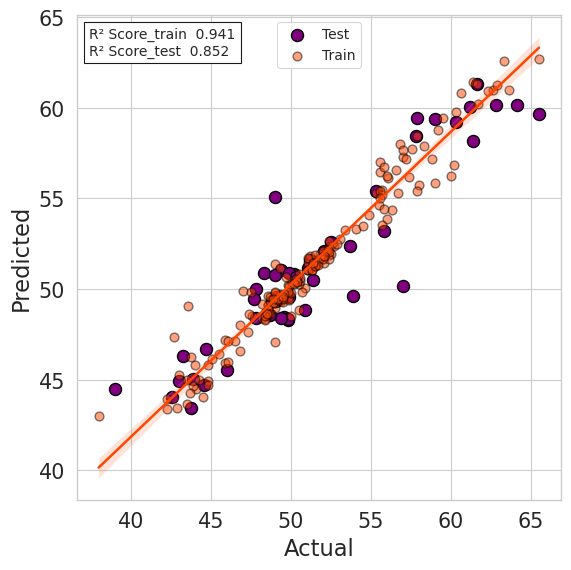

In [32]:
# Random Forest
model = defining_model(x = 'rndmfrst')
kfold = KFold(n_splits=5, shuffle=True)

scores = []
rmse = []
for train,valid in kfold.split(totalX,totalY):
  model.fit(totalX.iloc[train],totalY.iloc[train])
  scores.append(model.score(totalX.iloc[valid],totalY.iloc[valid]))
  actual = totalY.iloc[valid]
  predicted = model.predict(totalX.iloc[valid])
  rmse.append(sqrt(mean_squared_error(scaler.inverse_transform(actual),scaler.inverse_transform(predicted.reshape(-1,1)))))

print("Average validation R2 score after crossvalidation : ", np.mean(scores))
print("Average validation rmse score after crossvalidation : ", np.mean(rmse))


# Train model on whole train data
model = defining_model(x = 'rndmfrst')
model.fit(trainX,trainY)
print("\n\nTraining Accuracy : ",model.score(trainX,trainY)) # Training Accuracy
plots()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Average validation R2 score after crossvalidation :  0.7260619282722474
Average validation rmse score after crossvalidation :  2.5722961059221796
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


Training Accuracy :  0.9988571307268423
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Mean absolute error (MAE) - Test:      1.740419
Mean squared error (MSE) - Test:       5.919638
Root mean squared error (RMSE) - Test: 2.433031
R square (R^2):                 0.836368


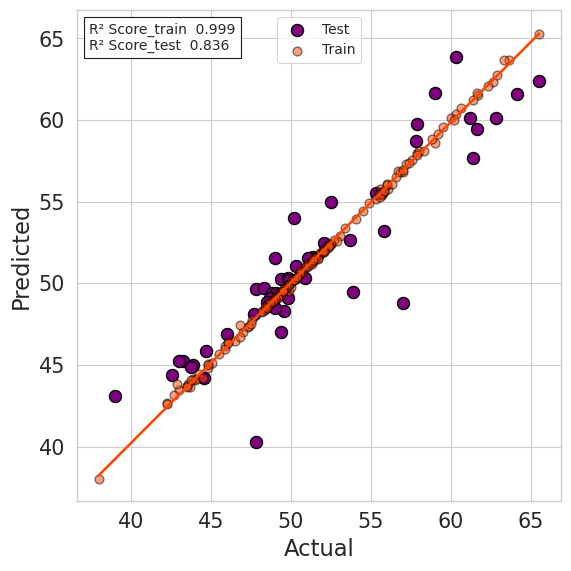

In [34]:
model = Neural_network()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []
rmse = []
for train,valid in kfold.split(totalX,totalY):
  model = Neural_network()
  training_model(totalX.iloc[train],totalY.iloc[train],model)
  scores.append(r2_score(totalY.iloc[valid],model.predict(totalX.iloc[valid])))

  actual = totalY.iloc[valid]
  predicted = model.predict(totalX.iloc[valid])
  rmse.append(sqrt(mean_squared_error(scaler.inverse_transform(actual),scaler.inverse_transform(predicted))))

print("Average validation R2 score after crossvalidation : ", np.mean(scores))
print("Average validation rmse score after crossvalidation : ", np.mean(rmse))

# # Train model on whole train data
tf.keras.backend.clear_session()
model = Neural_network()
training_model(trainX,trainY,model)

actual=np.array(scaler.inverse_transform(np.array(trainY)))
predicted=np.array(scaler.inverse_transform(model.predict(np.array(trainX)).reshape(-1,1)))
# model.save("nn.h5")
model.save('nn.keras')
score = r2_score(actual,predicted)
print("\n\nTraining Accuracy : ",score) # Training Accuracy
plots()